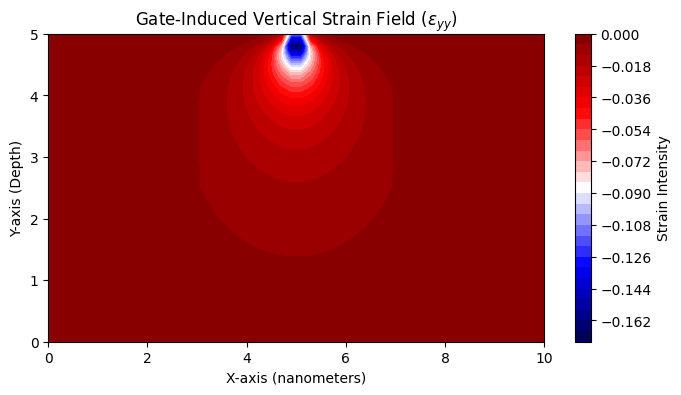

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 2D Silicon Chip Grid (50x50 atoms/nodes)
grid_size = 50
X, Y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 5, grid_size))

# Initialize displacement arrays (how much each point moves)
u_x = np.zeros_like(X)
u_y = np.zeros_like(Y)

# 2. Simulate a Nano-Gate pressing down on the top surface
# We apply a force in the middle of the top edge (Y = 5)
gate_center = 5.0
gate_width = 2.0

for i in range(grid_size):
    for j in range(grid_size):
        # Calculate distance from this pixel to the surface gate
        dx = X[i, j] - gate_center
        dy = 5.0 - Y[i, j] # Distance down from the top surface
        distance = np.sqrt(dx**2 + dy**2) + 0.5 # +0.5 prevents dividing by zero
        
        # Simple elasticity physics: force fades out the deeper/further it goes
        if X[i, j] > (gate_center - gate_width) and X[i, j] < (gate_center + gate_width):
            u_y[i, j] = -1.0 / distance  # Squeezing down (-Y)
            u_x[i, j] = (dx / distance) * 0.3  # Pushing atoms out sideways (+/- X)

# 3. Calculate Strain Fields (The change in displacement)
# Strain is just the gradient (derivative) of how much things moved
strain_xx = np.gradient(u_x, axis=1) # Horizontal strain (stretching/squeezing)
strain_yy = np.gradient(u_y, axis=0) # Vertical strain

# 4. Plot the Vertical Strain Field
plt.figure(figsize=(8, 4))
# 'seismic' map makes compression blue, zero strain white, and tension red
plt.contourf(X, Y, strain_yy, cmap="seismic", levels=30)
plt.colorbar(label="Strain Intensity")
plt.title("Gate-Induced Vertical Strain Field ($\epsilon_{yy}$)")
plt.xlabel("X-axis (nanometers)")
plt.ylabel("Y-axis (Depth)")
plt.show()

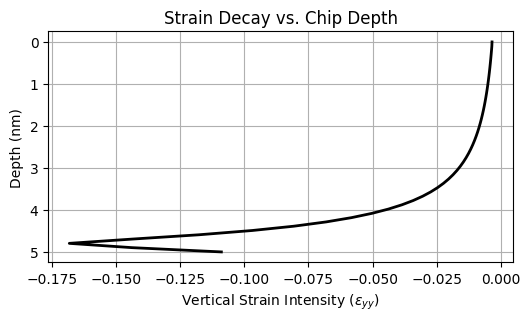

In [3]:
# Extract a vertical slice right down the middle of the gate (index 25)
middle_index = grid_size // 2
depth = Y[:, middle_index]
strain_at_center = strain_yy[:, middle_index]

plt.figure(figsize=(6, 3))
plt.plot(strain_at_center, depth, color="black", lw=2)
plt.gca().invert_yaxis() # Invert so top surface is at the top of the plot
plt.title("Strain Decay vs. Chip Depth")
plt.xlabel("Vertical Strain Intensity ($\epsilon_{yy}$)")
plt.ylabel("Depth (nm)")
plt.grid(True)
plt.show()

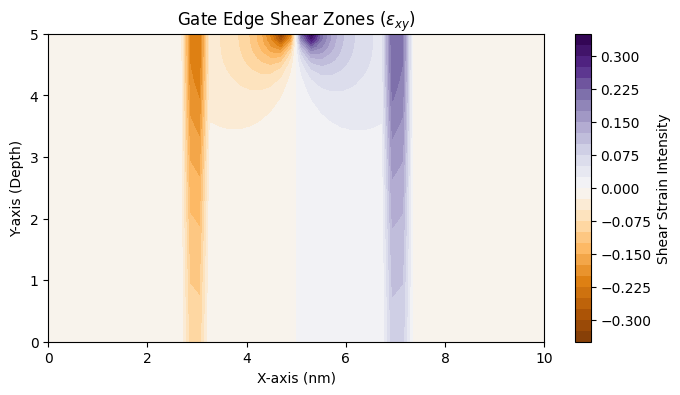

In [4]:
# Shear strain is the change of X-displacement as you go down Y, 
# plus the change of Y-displacement as you move across X.
strain_xy = np.gradient(u_x, axis=0) + np.gradient(u_y, axis=1)

plt.figure(figsize=(8, 4))
plt.contourf(X, Y, strain_xy, cmap="PuOr", levels=30) # Purple/Orange map works great for shear
plt.colorbar(label="Shear Strain Intensity")
plt.title("Gate Edge Shear Zones ($\epsilon_{xy}$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

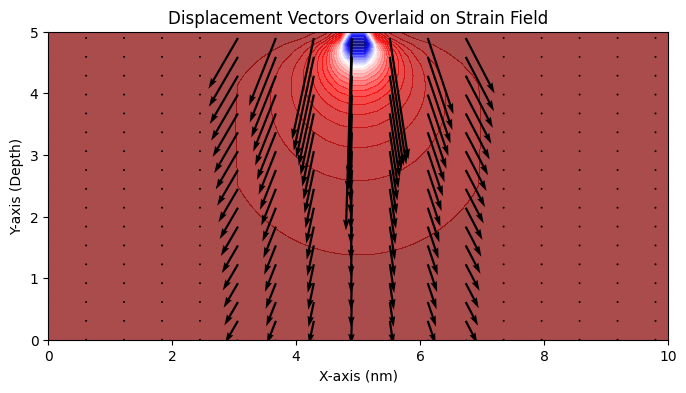

In [5]:
plt.figure(figsize=(8, 4))
# Plot the background strain map again
plt.contourf(X, Y, strain_yy, cmap="seismic", levels=30, alpha=0.7)

# Overlay arrows showing the displacement direction (skipping points so it's not crowded)
skip = (slice(None, None, 3), slice(None, None, 3))
plt.quiver(X[skip], Y[skip], u_x[skip], u_y[skip], color="black", scale=5)

plt.title("Displacement Vectors Overlaid on Strain Field")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

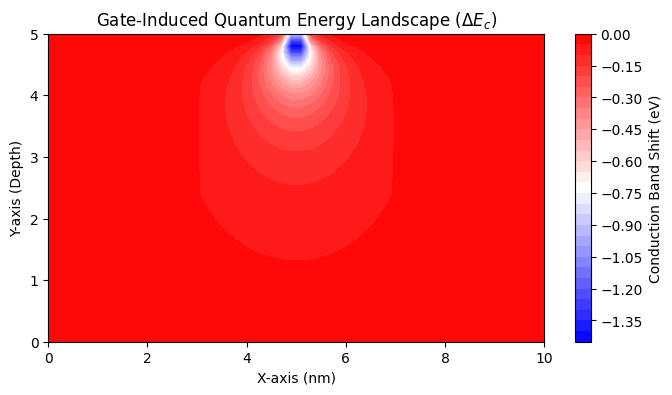

In [6]:
# Deformation potential for Silicon is roughly 8.6 electron-Volts (eV)
Xi = 8.6  

# Calculate the shifting energy landscapes for electrons across the chip
# Squeezing shifts the energy down, stretching shifts it up
energy_shift = Xi * strain_yy

plt.figure(figsize=(8, 4))
plt.contourf(X, Y, energy_shift, cmap="bwr", levels=30)
plt.colorbar(label="Conduction Band Shift (eV)")
plt.title("Gate-Induced Quantum Energy Landscape ($\Delta E_c$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

ValueError: cannot reshape array of size 27000 into shape (1,30)

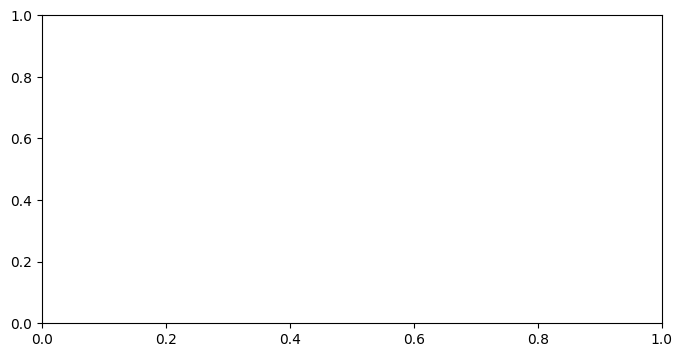

In [16]:
plt.figure(figsize=(8, 4))

# Plot a standard background wireframe of your chip
plt.pcolormesh(X, Y, energy_shift, cmap="hot", shading="auto", alpha=0.1)

# Draw distinct contour lines ONLY where the energy drop is severe
# This highlights the exact geometric boundaries of the quantum trap
cs = plt.contour(X, Y, energy_shift, levels=[-0.3, -0.2, -0.1], colors=["red", "orange", "yellow"])
plt.clabel(cs, inline=True, fontsize=8)

plt.title("Identifying Accidental Quantum Confinement Pockets")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

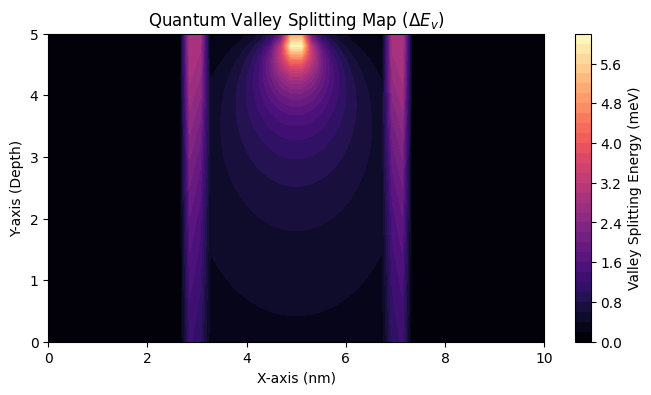

In [13]:
# 1. Define the valley coupling coefficient for Silicon (typically around 25 eV)
vo = 25.0  

# 2. Valley splitting is driven by the shear and asymmetry of the strain field
# We take the absolute difference between horizontal stretching and vertical squeezing
valley_splitting = vo * np.abs(strain_xx - strain_yy)

# 3. Plot the final Quantum Valley Map
plt.figure(figsize=(8, 4))
plt.contourf(X, Y, valley_splitting, cmap="magma", levels=30)
plt.colorbar(label="Valley Splitting Energy (meV)")

plt.title("Quantum Valley Splitting Map ($\Delta E_{v}$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

In [18]:
#3d

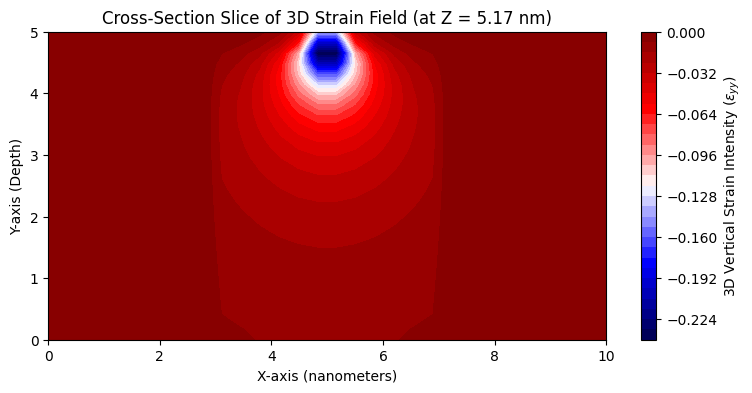

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 3D Silicon Block (30x30x30 grid)
grid_size = 30
x_range = np.linspace(0, 10, grid_size)
y_range = np.linspace(0, 5, grid_size)   # Depth axis
z_range = np.linspace(0, 10, grid_size)  # Width/Length axis

X, Y, Z = np.meshgrid(x_range, y_range, z_range, indexing='ij')

# Initialize 3D displacement arrays (movement in X, Y, and Z directions)
u_x = np.zeros_like(X)
u_y = np.zeros_like(Y)
u_z = np.zeros_like(Z)

# 2. Simulate a 3D Square Pad Gate on the top surface (Y = 5.0)
gate_x_center, gate_z_center = 5.0, 5.0
gate_radius = 2.0

for i in range(grid_size):
    for j in range(grid_size):
        for k in range(grid_size):
            # Calculate 3D distances from the center of the surface gate pad
            dx = X[i, j, k] - gate_x_center
            dy = 5.0 - Y[i, j, k]  # Distance down from top surface
            dz = Z[i, j, k] - gate_z_center
            
            # 3D spherical radius distance from the gate pad center
            distance_3d = np.sqrt(dx**2 + dy**2 + dz**2) + 0.5
            
            # Check if the node is directly underneath the square gate boundaries
            if abs(dx) < gate_radius and abs(dz) < gate_radius:
                # Forces push straight down (-Y) and radiate slightly outward (+/- X, +/- Z)
                u_y[i, j, k] = -1.5 / distance_3d
                u_x[i, j, k] = (dx / distance_3d) * 0.4
                u_z[i, j, k] = (dz / distance_3d) * 0.4

# 3. Calculate 3D Strain Fields (Partial derivatives along 3 axes)
# Axis=0 is X, Axis=1 is Y, Axis=2 is Z based on 'ij' indexing meshgrid
strain_xx = np.gradient(u_x, axis=0)  # Lateral strain (X)
strain_yy = np.gradient(u_y, axis=1)  # Vertical strain (Y depth)
strain_zz = np.gradient(u_z, axis=2)  # Lateral strain (Z width)

# 4. Slicing & Visualizing the 3D Volume
# Since monitors are 2D, we cut a slice right through the middle of the Z-axis (index 15)
mid_z_idx = grid_size // 2

plt.figure(figsize=(9, 4))
# Plot a 2D cross-section heatmap extracted from the 3D volume
plt.contourf(X[:, :, mid_z_idx], Y[:, :, mid_z_idx], strain_yy[:, :, mid_z_idx], cmap="seismic", levels=35)
plt.colorbar(label="3D Vertical Strain Intensity ($\epsilon_{yy}$)")

plt.title(f"Cross-Section Slice of 3D Strain Field (at Z = {Z[0, 0, mid_z_idx]:.2f} nm)")
plt.xlabel("X-axis (nanometers)")
plt.ylabel("Y-axis (Depth)")
plt.show()